In [2]:
from dino import DINO_vectors_func

from PCA_kmeans import PCA_func, Kernal_PCA_func
from anomaly_photo import anomaly_photo_func

/opt/anaconda3/envs/neuroshock/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 10772.96it/s]


In [81]:
directory = '/Users/user/Desktop/НИС_2/Бутылки_165'
#directory = '/Users/user/Desktop/НИС_2/Рентген_305'
directory = '/Users/user/Desktop/ВКР_ИТМО/yolo_seg_dataset_CAP_final/train/images'



directory = '/Users/user/Desktop/ВКР_ИТМО/CAP_anomaly'

glob, result_vectors = DINO_vectors_func(directory)

top_farthest_points_idx = PCA_func(result_vectors, n_components=25, top_k = 10)

Обработано 43/43 изображений
Получено векторов: 43
Размерность вектора: 768
Суммарная объяснённая доля для 25 компонент: 0.973
Кластеров: 2


In [79]:
from sklearn.ensemble import IsolationForest
import numpy as np

def isolation_forest_outliers(result_vectors, contamination=0.05):
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    preds = iso_forest.fit_predict(result_vectors)  # -1 = выброс
    outlier_indices = np.where(preds == -1)[0]
    return outlier_indices  # можно взять top_k по score



top_farthest_points_idx = isolation_forest_outliers(result_vectors, contamination=0.06)

In [87]:
from sklearn.svm import OneClassSVM
import numpy as np

def oneclasssvm_outliers(result_vectors, contamination=0.05):
    ocsvm = OneClassSVM(nu=contamination, kernel='rbf')
    preds = ocsvm.fit_predict(result_vectors)  # -1 = выброс, 1 = нормальный
    outlier_indices = np.where(preds == -1)[0]
    return outlier_indices

top_farthest_points_idx = oneclasssvm_outliers(result_vectors, contamination=0.05)

In [86]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pca = PCA(n_components=25)

X_scaled = scaler.fit_transform(result_vectors)
result_vectors = pca.fit_transform(X_scaled)

№_1   WIN_20210818_16_34_48_Pro_jpg.rf.da296892a4590c16003054225ccd4cf3.jpg


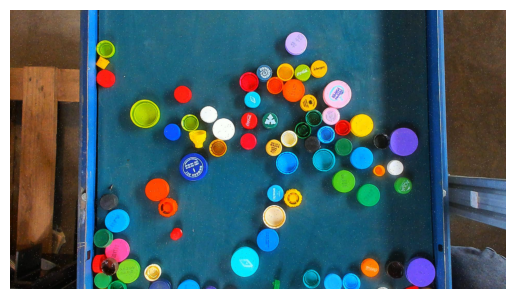

№_2   WIN_20210818_16_42_03_Pro_jpg.rf.9c6248318fa10dea5cb0f87c33b5b385.jpg


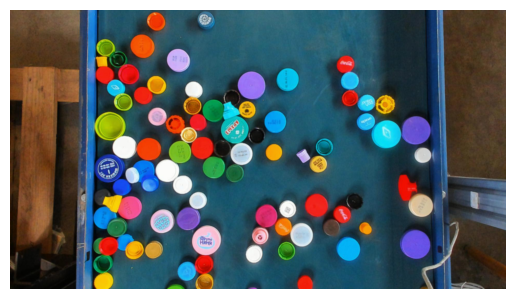

№_3   output_R3.png


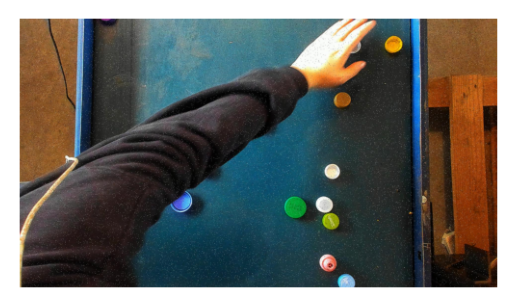

№_4   WIN_20210818_16_44_39_Pro_jpg.rf.6b4dca1bd877fabad9f0c7dcf8ff0291.jpg


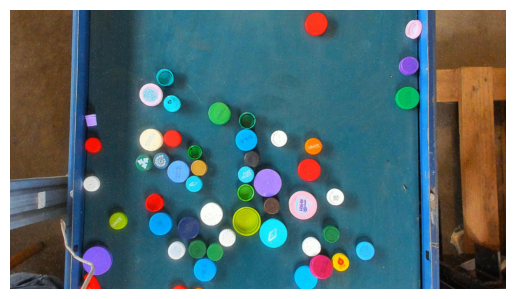

№_5   output_R1.png


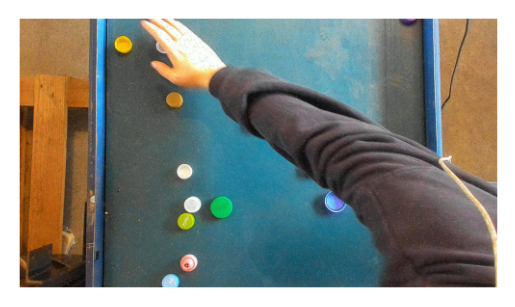

№_6   WIN_20210818_16_43_57_Pro_jpg.rf.805a87a8a3d985bc7ddc418e034df944.jpg


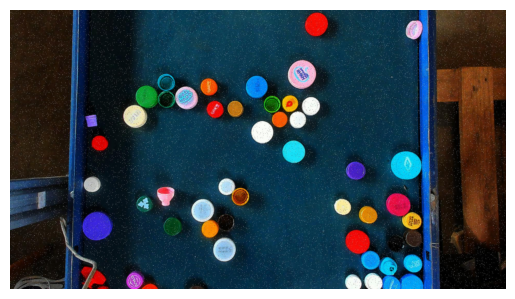

№_7   WIN_20210818_16_43_57_Pro_jpg.rf.0fda48dfbc784451a549fd755c1bac13.jpg


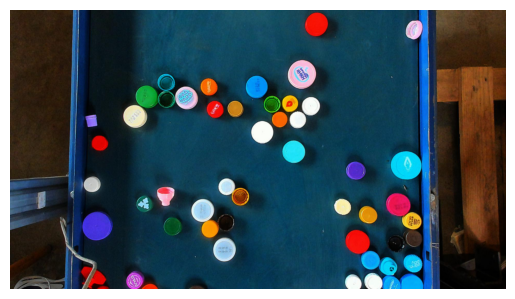

№_8   WIN_20210818_16_43_49_Pro_jpg.rf.ad9dc077bac758f4fa89d14d1895ddec.jpg


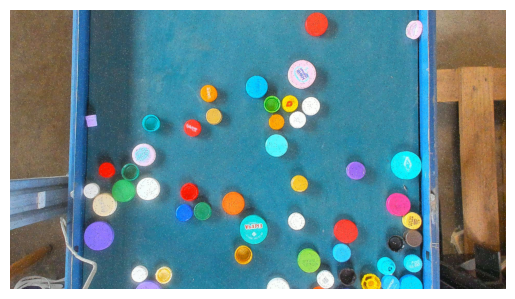

№_9   WIN_20210818_16_43_57_Pro_jpg.rf.b2d8cf5317989075b126efa74f404427.jpg


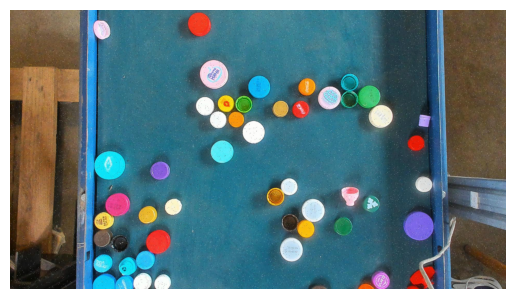

№_10   WIN_20210818_16_34_42_Pro_jpg.rf.09cdf25a127ff366977cb54a1d20d6f2.jpg


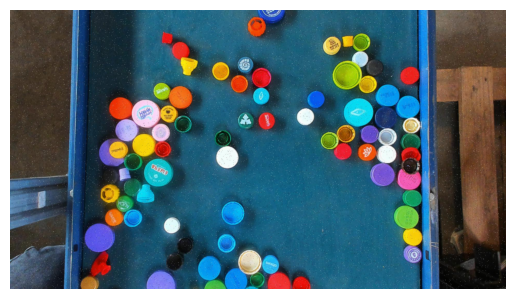

№_11   WIN_20210818_16_34_48_Pro_jpg.rf.4b394e5cfd355fb66d04317151b5863d.jpg


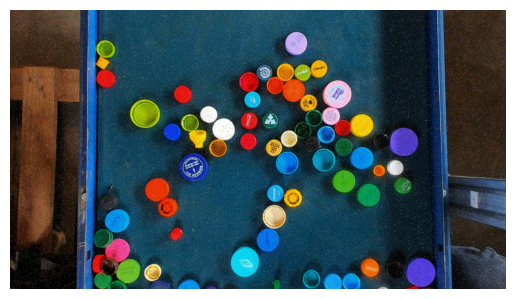

№_12   WIN_20210818_16_44_14_Pro_jpg.rf.d15abb96149e5158c21ac5ad4acdba8e.jpg


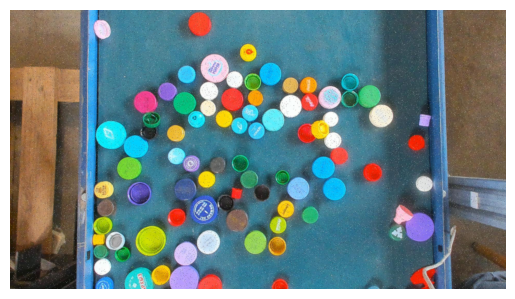

In [88]:
anomaly_photo_func(glob, top_farthest_points_idx)